# 2章 ネットワークと時間

コンピュータネットワークにおいて、時間は重要な観点です。
現実世界におけるデータのやり取りには時間がかかりますし、私たちが体感する「品質」にも大きく関わってくるためです。
例えば、映像のデータの転送に時間がかかれば、快適に視聴することができません。
ただし、プロトコルの仕組みなどを座学として学ぶような類書では、あまり時間の概念には触れません。
本章では、シミュレータへ時間の概念を実装していきます。
なお、後の章のために必要となる準備も含むため、難しいところも出てくるかもしれません。
そういった部分は読み飛ばして、次の章へと進んでも問題ありません。

## 時間の重要性
### データの連続的な送信
コンピュータネットワークでは、データは一連のパケット（小さなデータの塊）として送信されます。
これらのパケットは、一つずつ、または小さなグループで、時間をかけて送られます。
例えば、大きなファイルをメールで送る場合、そのファイルは多くの小さなパケットに分割され、それぞれがネットワークを通じて目的地に向かいます。
これらのパケットは、一度にすべてが送られるのではなく、時間をかけて順番に送られるのです。

### 大きなデータの送信時間
データのサイズが大きいほど、送信にかかる時間も長くなります。
これは、ネットワークの帯域幅（一定時間内に送信できるデータの量）によって制限されるためです。
例えば、高速なインターネット接続では、大きなファイルも比較的短時間で送信できますが、遅い接続では時間がかかります。

### 信号の伝搬時間
データが物理的に遠い場所に送信される場合、信号が伝わるのに時間がかかります。
これは、光ファイバや銅線、空気などの物理的な媒体を通じてデータが移動する速度に依存します。
たとえば、地球の反対側にあるサーバにアクセスするとき、信号が伝わるのに数十ミリ秒から数百ミリ秒かかることがあります。

### ネットワークの混雑と遅延
ネットワークが混雑していると、データの送信に遅延が生じます。
これは、多くのデータが同時に同じルートを通ると、パケットが待機しなければならないためです。
この現象は、高速道路の渋滞に似ています。
混雑がひどいと、データの到着が大幅に遅れることがあります。

### 遅延の体感品質への影響
遅延は、特にリアルタイム通信（例えば、ビデオ通話やオンラインゲーム）で体感品質に大きな影響を与えます。
遅延が大きいと、通話が途切れたり、ゲームでの反応が遅れたりすることがあります。
これは、データが送信されてから受信されるまでの時間が長くなるため、ユーザー体験が悪化するのです。


## `Packet`クラスの改良

### 設計方針
前章で作成した `Packet` クラスは、非常にシンプルなものでした。
そのため、時間の概念を導入しつつ、今後の拡張にも耐えられるように、以下のような修正を加えます。

#### 1. パケットIDの追加
原型の `Packet` クラスには、パケットに固有の識別子（ID）がなく、識別ができませんでした。
シミュレータ上では、パケットを識別できた方が理解しやすいので、`uuid.uuid4()` を使用して、各パケットに一意のIDを割り当てています。
これにより、ネットワーク上で個々のパケットを簡単に識別し、追跡することが可能になります。

#### 2. ヘッダ情報の導入
パケットの送信元と宛先が、単純なインスタンス変数として保持されていました。
実際には、パケットはヘッダと呼ばれる情報と、ペイロードと呼ばれる本体から構成されています。
ヘッダには、様々なアドレスなど、ネットワーク上でのデータ送受信に必要な情報が書き込まれています。
具体的な内容については後の章で扱いますが、ここではヘッダの原型を整えておきます。
ここでは、送信元と宛先を `header` という辞書に格納します。
これにより、将来的にヘッダに他のメタデータ（例えば、タイムスタンプやプロトコル情報など）を追加しやすくなります。
また、ヘッダとペイロードを区別することで、実際のネットワークパケットの構造をより現実的に模倣しています。

#### 3. パケットサイズの計算
原型のクラスでは、パケットのサイズに関する情報は含まれていません。
実際のデバイスでは、パケットのサイズに応じた処理時間がかかるので、時間の概念を導入するに当たって、パケットサイズの概念も必須となります。
改良版では、ヘッダとペイロードのサイズを合計して、パケット全体のサイズを計算しています。
これは、ネットワークの帯域幅の使用量を計算する際に重要な情報となります。
なお一般的に、パケットサイズはバイト数で表現されます。

#### 4. タイムスタンプの追加
原型のクラスには、パケットの生成時刻や到着時刻を記録する機能がありません。
ネットワーク上でのパケットの挙動をトレースし理解するために、パケットの生成時刻 (`creation_time`) と到着時刻 (`arrival_time`) を記録するように修正します。
このアップデートにより、ネットワークの遅延やパフォーマンスの分析が可能になります。

#### 5. heapqでの使用を考慮したメソッドの追加
原型のクラスには、Pythonの`heapq`モジュール（優先度付きキューを実装するためのモジュール）での使用を考慮したメソッドは含まれていません。
これはシミュレーションの都合ですが、`__lt__` メソッドを追加し、`heapq`を用いてパケットを適切に管理できるようにしています。
ただし、この点について理解が難しい場合には、読み飛ばして構いません。




### アップデート版`Packet`クラスの実装
#### 1. `network_event_scheduler`の統合
```
self.network_event_scheduler = network_event_scheduler
```
原型のクラスでは、パケットの送受信ログを直接printしていました。
改良版では、`network_event_scheduler` を使用してパケットの挙動をトレースすることで、ネットワークの動作をより詳細にシミュレートできるようにしています。

#### 2. パケットIDの生成
```
self.id = str(uuid.uuid4())
```
ここでは、`uuid.uuid4()` 関数を使用して、各パケットに一意のIDを割り当てています。これにより、ネットワーク上で個々のパケットを簡単に識別し、追跡することが可能になります。

#### 3. ヘッダ情報の定義
```
self.header = {
    "source": source,
    "destination": destination,
}
```
パケットのヘッダ情報は、送信元（`source`）と宛先（`destination`）のアドレスを含む辞書として定義されています。この辞書形式の使用は、将来的にヘッダに他の種類のメタデータを追加する際に柔軟性を提供します。

#### 4. パケットサイズの計算
```
self.payload = 'X' * payload_size
self.size = header_size + payload_size
```
ここでは、ヘッダとペイロードのバイト長を加えることで、パケット全体のサイズが求められます。このサイズ情報は、ネットワークの帯域幅の使用量を計算する際に重要です。

#### 5. タイムスタンプの記録
```
self.creation_time = self.network_event_scheduler.current_time
self.arrival_time = None
```
パケットの生成時刻は、`network_event_scheduler`（後述）の現在時刻を使用して記録されます。また、到着時刻は初期値として`None`が設定され、後で`set_arrived`メソッドを通じて設定されます。これにより、ネットワークの遅延やパフォーマンスを分析することが可能になります。

#### 6. heapqモジュールでの使用
```
def __lt__(self, other):
    return False
```
このメソッドは、Pythonの`heapq`モジュール（優先度付きキューを実装するためのモジュール）での使用を考慮しています。現在の実装では比較を行わないため、常に False を返していますが、必要に応じて比較ロジックを追加することができます。

#### 7. 文字列表現の提供
```
def __str__(self):
    return f'パケット(送信元: {self.header["source"]}, 宛先: {self.header["destination"]}, ペイロード: {self.payload})'
```
`__str__`メソッドは、パケットの内容を人間が読みやすい形式で表現します。これにより、デバッグやログ出力時にパケットの詳細を簡単に確認することができます。

結果として、`Packet`は以下のようなクラスとして実装されます。


In [ ]:
import uuid  # UUIDモジュールをインポート

class Packet:
    # Packetクラスのコンストラクタ
    def __init__(self, source, destination, header_size, payload_size, network_event_scheduler):
        self.network_event_scheduler = network_event_scheduler
        self.id = str(uuid.uuid4())  # パケットに一意のID（UUID）を割り当てる

        # パケットのヘッダ情報を辞書で定義
        self.header = {
            "source": source,         # 送信元アドレス
            "destination": destination,  # 宛先アドレス
        }
        self.payload = 'X' * payload_size  # パケットのペイロード（実際に送信するデータ）
        self.size = header_size + payload_size  # パケット全体のサイズ
        self.creation_time = self.network_event_scheduler.current_time  # パケット生成時刻の記録
        self.arrival_time = None  # パケット到着時刻（初期値はNone）

    # 到着時刻を設定するメソッド
    def set_arrived(self, arrival_time):
        self.arrival_time = arrival_time  # 到着時刻を設定

    # heapqモジュールでの比較のための特殊メソッド
    # この実装では比較を行わないため、常にFalseを返す
    def __lt__(self, other):
        return False

    # パケットの文字列表現を返す特殊メソッド
    def __str__(self):
        return f'パケット(送信元: {self.header["source"]}, 宛先: {self.header["destination"]}, ペイロード: {self.payload})'


## `Link`クラスの改良
### 設計方針
前章で作成した `Link` クラスも、非常にシンプルなものでした。
そのため、時間の概念を導入しつつ、今後の拡張にも耐えられるように、以下のような修正を加えます。

#### 1. パケットキューの導入
前章の`Link`クラスでは、時間の概念がなかったため、パケットは即座に次のノードに転送されていました。
それだと、現実のネットワークのように次々にパケットを転送するような場合に、うまく動作しません。
そのため、パケットを保持するパケットキューを導入します。
また、パケットを送る方向の識別も必要なので、`packet_queue_xy` と `packet_queue_yx` という2つのキューを作成しています。
これらのキューは、リンクを通過するパケットを一時的に格納し、リンクの帯域幅や遅延に基づいて順序よく転送するために使用されます。
これにより、実際のネットワークの帯域幅制限や遅延をより現実的にシミュレートできます。

#### 2. 帯域幅と遅延の詳細な扱い
原型のクラスでは、帯域幅と遅延は単純な数値として扱われています。
改良版では、帯域幅と遅延をより詳細に扱っています。
特に、パケットのサイズと帯域幅を考慮して、パケットの転送にかかる時間を計算しています。
これにより、ネットワークのトラフィックが多い場合の遅延や、帯域幅の制限がパケット転送に与える影響をシミュレートすることが可能になります。

#### 3. パケットロスのシミュレーション
原型のクラスでは、パケットロスの概念がありませんでした。
改良版では、`loss_rate` パラメータが導入され、パケットロスのシミュレーションが可能になっています。
これにより、ネットワークの品質や信頼性の問題を模倣し、パケットロスが発生した場合のネットワークの挙動を分析できます。

#### 4. heapqを使用したパケットのスケジューリング
原型のクラスでは、パケットのスケジューリングに関する言及がありません。
改良版では、heapq モジュールを使用してパケットの転送イベントをスケジュールしています。
これにより、複数のパケットがキューに存在する場合に、それらを効率的に管理し、正確な順序で転送することができます。

### アップデート版`Link`クラスの実装
#### リンクの基本的な特性
```
self.node_x = node_x  # リンクの一方のノード
self.node_y = node_y  # リンクの他方のノード
self.bandwidth = bandwidth  # リンクの帯域幅（bps）
self.delay = delay  # リンクの遅延（秒）
self.loss_rate = loss_rate  # パケットロス率
```
リンクは2つのノード（`node_x` と `node_y`）を接続します。各リンクは帯域幅（`bandwidth`）、遅延（`delay`）、パケットロス率（`loss_rate`）といった特性を持ちます。これらの特性は、リンクを通過するパケットの挙動に影響を与えます。

#### パケットキューの管理
```
self.packet_queue_xy = []  # node_xからnode_yへのパケットキュー
self.packet_queue_yx = []  # node_yからnode_xへのパケットキュー
```
`Link`クラスは、各方向に対してパケットキューを持っています。これらのキューは、リンクを通過するパケットを一時的に格納し、リンクの帯域幅や遅延に基づいて順序よく転送するために使用されます。

#### パケットのエンキューと転送
```
def enqueue_packet(self, packet, from_node):
    # ...
    heapq.heappush(queue, (dequeue_time, packet, from_node))

def transfer_packet(self, from_node):
    # ...
    self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time + self.delay, next_node.receive_packet, packet)
```
パケットは、`enqueue_packet` メソッドを通じてキューに追加されます。その後、`transfer_packet` メソッドによって、適切なタイミングで次のノードに転送されます。このプロセスは、リンクの帯域幅と遅延を考慮して行われます。

#### パケットロスのシミュレーション
```
if random.random() < self.loss_rate:
    packet.set_arrived(-1)  # ロスパケットにフラグを付与
```
リンクは、設定されたパケットロス率に基づいて、ランダムにパケットを失うことがあります。これにより、ネットワークの品質や信頼性の問題を模倣し、パケットロスが発生した場合のネットワークの挙動を分析できます。

#### heapqを使用した効率的なスケジューリング
```
import heapq
```
`Link`クラスは `heapq` モジュールを使用して、パケットの転送イベントを効率的にスケジュールします。これにより、複数のパケットがキューに存在する場合に、それらを効率的に管理し、正確な順序で転送することができます。

結果として、`Link`は以下のようなクラスとして実装されます。


In [ ]:
import heapq  # heapqモジュールをインポート（優先度付きキューのため）
import random  # randomモジュールをインポート（パケットロスのシミュレーションのため）

class Link:
    # Linkクラスのコンストラクタ
    def __init__(self, node_x, node_y, bandwidth, delay, loss_rate, network_event_scheduler):
        self.network_event_scheduler = network_event_scheduler
        self.node_x = node_x  # リンクの一方のノード
        self.node_y = node_y  # リンクの他方のノード
        self.bandwidth = bandwidth  # リンクの帯域幅（bps）
        self.delay = delay  # リンクの遅延（秒）
        self.loss_rate = loss_rate  # パケットロス率
        self.packet_queue_xy = []  # node_xからnode_yへのパケットキュー
        self.packet_queue_yx = []  # node_yからnode_xへのパケットキュー
        self.current_queue_time_xy = 0  # node_xからnode_yへのキュー時間
        self.current_queue_time_yx = 0  # node_yからnode_xへのキュー時間
        node_x.add_link(self)  # node_xにこのリンクを追加
        node_y.add_link(self)  # node_yにこのリンクを追加
        label = f'{bandwidth/1000000} Mbps, {delay} s'
        self.network_event_scheduler.add_link(node_x.node_id, node_y.node_id, label, self.bandwidth, self.delay)

    # パケットをキューに追加するメソッド
    def enqueue_packet(self, packet, from_node):
        # xy方向かyx方向かを判定
        if from_node == self.node_x:
            queue = self.packet_queue_xy
            current_queue_time = self.current_queue_time_xy
        else:
            queue = self.packet_queue_yx
            current_queue_time = self.current_queue_time_yx

        # 当該パケットの転送に要する時間を計算
        packet_transfer_time = (packet.size * 8) / self.bandwidth
        # パケットのデキュー予定時刻を計算
        dequeue_time = self.network_event_scheduler.current_time + current_queue_time
        # パケットをキューに追加し、キュー時間を更新
        heapq.heappush(queue, (dequeue_time, packet, from_node))
        self.add_to_queue_time(from_node, packet_transfer_time)
        # 最初のパケットの場合、イベントをスケジュール
        if len(queue) == 1:
            self.network_event_scheduler.schedule_event(dequeue_time, self.transfer_packet, from_node)

    # パケットを転送するメソッド
    def transfer_packet(self, from_node):
        # xy方向かyx方向かを判定
        if from_node == self.node_x:
            queue = self.packet_queue_xy
        else:
            queue = self.packet_queue_yx

        if queue:
            dequeue_time, packet, _ = heapq.heappop(queue)
            packet_transfer_time = (packet.size * 8) / self.bandwidth

            # 確率的にパケットロスを発生させる
            if random.random() < self.loss_rate:
                packet.set_arrived(-1)  # ロスパケットにフラグを付与

            next_node = self.node_x if from_node != self.node_x else self.node_y
            # 遅延を考慮したイベントスケジュール
            self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time + self.delay, next_node.receive_packet, packet)
            self.network_event_scheduler.schedule_event(dequeue_time + packet_transfer_time, self.subtract_from_queue_time, from_node, packet_transfer_time)

            # 次のパケットがある場合、そのイベントをスケジュール
            if queue:
                next_packet_time = queue[0][0]
                self.network_event_scheduler.schedule_event(next_packet_time, self.transfer_packet, from_node)

    # キュー時間を増やすメソッド
    def add_to_queue_time(self, from_node, packet_transfer_time):
        if from_node == self.node_x:
            self.current_queue_time_xy += packet_transfer_time
        else:
            self.current_queue_time_yx += packet_transfer_time

    # キュー時間を減らすメソッド
    def subtract_from_queue_time(self, from_node, packet_transfer_time):
        if from_node == self.node_x:
            self.current_queue_time_xy -= packet_transfer_time
        else:
            self.current_queue_time_yx -= packet_transfer_time

    # リンクの文字列表現を返す特殊メソッド
    def __str__(self):
        return f"リンク({self.node_x.node_id} ↔ {self.node_y.node_id}, 帯域幅: {self.bandwidth}, 遅延: {self.delay}, パケットロス率: {self.loss_rate})"


## `Node`クラスの改良
### 設計方針
改良版の `Node` クラスは、原型の `Node` クラスにいくつかの重要な機能を追加し、より実用的で詳細なネットワークシミュレーションを可能にしています。
以下に、主な改良点を詳細に説明します。

#### 1. ネットワークイベントスケジューラの統合
原型のクラスでは、ノードの作成やリンクの追加を `network_graph` オブジェクトに対して行い、可視化を行っていました。
改良版では、`network_event_scheduler` を使用してノードの作成やリンクの追加を行っています。
これにより、ネットワークイベント（パケットの生成、送受信など）を時間軸に沿ってスケジュールし、ネットワークの動作をより詳細にシミュレートできるようにしています。

#### 2. パケットの詳細なログ記録
原型のクラスでは、パケットの送受信時に単純なプリント文を使用していましたが、そのままでは結果の理解が難しくなってきます。
そこで改良版では、`network_event_scheduler` を通じてパケットの生成、送信、受信、到着、ロスなどの詳細なログを記録しています。
これにより、ネットワークのパフォーマンス分析やトラブルシューティングが容易になります。

#### 3. パケットの送信ロジックの拡張
原型のクラスでは、パケットが宛先に到達したかどうかの単純なチェックのみを行っていました。
改良版では、パケットの宛先が自ノードであるかどうかをチェックし、そうでない場合はリンクを通じて次のノードにパケットを転送するロジックを含んでいます。

#### 4. トラフィック生成機能の追加
原型のクラスには、トラフィックを生成する機能がありませんでした。
改良版では、`set_traffic` メソッドを通じて特定の宛先に対するトラフィックを設定できます。
様々なアプリケーションを想定したパラメタでパケットを生成し、ネットワークのパフォーマンスを評価できるようにしています。


### アップデート版`Node`クラスの実装
#### ノードの基本的な特性
```python
self.node_id = node_id  # ノードのID
self.address = address  # ノードのアドレス
```
各ノードは一意のIDとアドレスを持ちます。これらはネットワーク内でノードを識別するために使用されます。

#### リンクの管理
```python
self.links = []  # このノードに接続されているリンクのリスト

def add_link(self, link):
    if link not in self.links:
        self.links.append(link)  # リンクがまだリストになければ追加
```
ノードは、自身に接続されているリンクのリストを管理します。新しいリンクが作成されると、それはこのリストに追加されます。

#### パケットの受信とログ記録
```python
def receive_packet(self, packet):
    # パケットロスや到着のログ記録
```
ノードはパケットを受信すると、そのパケットが失われたか、正常に到着したかを判断し、適切なログを記録します。これにより、ネットワークのパフォーマンス分析やトラブルシューティングが容易になります。

#### パケットの送信
```python
def send_packet(self, packet):
    # パケットの送信とログ記録
```
ノードはパケットを送信する際、そのパケットが自分自身宛てであれば直接受信処理を行い、そうでなければ接続されているリンクを通じて次のノードに転送します。このプロセスは、ネットワーク上でのパケットのルーティングをシミュレートします。

#### パケットの生成とトラフィックの設定
```python
def create_packet(self, destination, payload):
    # パケットの生成と送信

def set_traffic(self, destination, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0):
    # 定義されたビットレートと期間に基づいてパケットを生成し、送信
```
ノードは特定の宛先に対してパケットを生成し、送信することができます。また、`set_traffic` メソッドを使用して、定義されたビットレートと期間に基づいて連続的にパケットを生成し、送信することができます。これにより、ネットワークの負荷テストや性能評価を行うことができます。

#### ノードの文字列表現
```python
def __str__(self):
    # ノードの情報を文字列で表現
```
`__str__` メソッドは、ノードのID、アドレス、接続されているノードのIDを含む文字列を返します。これにより、ノードの状態を簡単に確認することができます。

結果として、`Node`は以下のようなクラスとして実装されます。


In [ ]:
class Node:
    # Nodeクラスのコンストラクタ
    def __init__(self, node_id, address, network_event_scheduler):
        self.network_event_scheduler = network_event_scheduler
        self.node_id = node_id  # ノードのID
        self.address = address  # ノードのアドレス
        self.links = []  # このノードに接続されているリンクのリスト
        label = f'Node {node_id}\n{address}'
        self.network_event_scheduler.add_node(node_id, label)  # ネットワークイベントスケジューラにノードを追加

    # リンクを追加するメソッド
    def add_link(self, link):
        if link not in self.links:
            self.links.append(link)  # リンクがまだリストになければ追加

    # パケットを受信するメソッド
    def receive_packet(self, packet):
        # パケットが失われた場合（到着時間が-1の場合）の処理
        if packet.arrival_time == -1:
            self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)  # パケットのロスをログに記録
            return
        # パケットが正常に到着した場合の処理
        if packet.header["destination"] == self.address:
            self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)  # パケットの到着をログに記録
            packet.set_arrived(self.network_event_scheduler.current_time)  # 到着時刻を設定
        else:
            self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)  # パケットの受信をログに記録
            # ここで宛先が自分自身でない場合の追加処理を行う（現在はpass）

    # パケットを送信するメソッド
    def send_packet(self, packet):
        self.network_event_scheduler.log_packet_info(packet, "sent", self.node_id)  # パケットの送信をログに記録
        if packet.header["destination"] == self.address:
            self.receive_packet(packet)  # 宛先が自分自身の場合は受信処理を行う
        else:
            for link in self.links:
                next_node = link.node_x if self != link.node_x else link.node_y
                link.enqueue_packet(packet, self)  # リンクを通じてパケットを送信
                break  # 最初のリンクを使って送信した後、ループを抜ける

    # パケットを生成するメソッド
    def create_packet(self, destination, header_size, payload_size):
        packet = Packet(source=self.address, destination=destination, header_size=header_size, payload_size=payload_size, network_event_scheduler=self.network_event_scheduler)  # パケットを生成
        self.network_event_scheduler.log_packet_info(packet, "created", self.node_id)  # パケットの生成をログに記録
        self.send_packet(packet)  # 生成したパケットを送信

    # トラフィックを設定するメソッド
    def set_traffic(self, destination, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0):
        end_time = start_time + duration  # トラフィックの終了時刻
        def generate_packet():
            if self.network_event_scheduler.current_time < end_time:
                self.create_packet(destination, header_size, payload_size)  # パケットを生成して送信
                packet_size = header_size + payload_size
                interval = (packet_size * 8) / bitrate * burstiness  # 次のパケットを生成するまでの間隔
                self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time + interval, generate_packet)

        self.network_event_scheduler.schedule_event(start_time, generate_packet)  # 最初のパケット生成イベントをスケジュール

    # ノードの文字列表現を返す特殊メソッド
    def __str__(self):
        # 接続されているノードのIDを取得
        connected_nodes = [link.node_x.node_id if self != link.node_x else link.node_y.node_id for link in self.links]
        connected_nodes_str = ', '.join(map(str, connected_nodes))
        return f"ノード(ID: {self.node_id}, アドレス: {self.address}, 接続: {connected_nodes_str})"


### 本章での実装まとめ
ここまでに説明してきた`Packet`，`Link`および`Node`の3クラスに加えて、可視化やログの集計を担う`NetworkEventScheduler`クラスを定義したコードを示します。
少し煩雑となるため`NetworkEventScheduler`クラスの詳細については解説していませんが、細かく理解せずとも支障はありませんので、気にせず進めて大丈夫です。
以降では、このコードをベースにしてシミュレーションを実行し、ログを見ながら挙動を確認していきます。
以下のコードブロックを忘れずに実行してください。


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import heapq
import uuid
import random
import numpy as np
from collections import defaultdict

class NetworkEventScheduler:
    def __init__(self, log_enabled=False, verbose=False):
        self.current_time = 0
        self.events = []
        self.event_id = 0
        self.packet_logs = {}
        self.log_enabled = log_enabled
        self.verbose = verbose
        self.graph = nx.Graph()

    def add_node(self, node_id, label):
        self.graph.add_node(node_id, label=label)

    def add_link(self, node1_id, node2_id, label, bandwidth, delay):
        self.graph.add_edge(node1_id, node2_id, label=label, bandwidth=bandwidth, delay=delay)

    def draw(self):
        def get_edge_width(bandwidth):
            return np.log10(bandwidth) + 1

        def get_edge_color(delay):
            if delay <= 0.001:  # <= 1ms
                return 'green'
            elif delay <= 0.01:  # 1-10ms
                return 'yellow'
            else:  # >= 10ms
                return 'red'

        pos = nx.spring_layout(self.graph)
        edge_widths = [get_edge_width(self.graph[u][v]['bandwidth']) for u, v in self.graph.edges()]
        edge_colors = [get_edge_color(self.graph[u][v]['delay']) for u, v in self.graph.edges()]

        nx.draw(self.graph, pos, with_labels=False, node_color='lightblue', node_size=2000, width=edge_widths, edge_color=edge_colors)
        nx.draw_networkx_labels(self.graph, pos, labels=nx.get_node_attributes(self.graph, 'label'))
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=nx.get_edge_attributes(self.graph, 'label'))
        plt.show()

    def schedule_event(self, event_time, callback, *args):
        event = (event_time, self.event_id, callback, args)
        heapq.heappush(self.events, event)
        self.event_id += 1

    def log_packet_info(self, packet, event_type, node_id=None):
        if self.log_enabled:
            if packet.id not in self.packet_logs:
                self.packet_logs[packet.id] = {
                    "source": packet.header["source"],
                    "destination": packet.header["destination"],
                    "size": packet.size,
                    "creation_time": packet.creation_time,
                    "arrival_time": packet.arrival_time,
                    "events": []
                }

            if event_type == "arrived":
                self.packet_logs[packet.id]["arrival_time"] = self.current_time

            event_info = {
                "time": self.current_time,
                "event": event_type,
                "node_id": node_id,
                "packet_id": packet.id,
                "src": packet.header["source"],
                "dst": packet.header["destination"]
            }
            self.packet_logs[packet.id]["events"].append(event_info)

            if self.verbose:
                print(f"Time: {self.current_time} Node: {node_id}, Event: {event_type}, Packet: {packet.id}, Src: {packet.header['source']}, Dst: {packet.header['destination']}")


    def print_packet_logs(self):
        for packet_id, log in self.packet_logs.items():
            print(f"Packet ID: {packet_id} Src: {log['source']} {log['creation_time']} -> Dst: {log['destination']} {log['arrival_time']}")
            for event in log['events']:
                print(f"Time: {event['time']}, Event: {event['event']}")

    def generate_summary(self, packet_logs):
        summary_data = defaultdict(lambda: {"sent_packets": 0, "sent_bytes": 0, "received_packets": 0, "received_bytes": 0, "total_delay": 0, "lost_packets": 0, "min_creation_time": float('inf'), "max_arrival_time": 0})

        for packet_id, log in packet_logs.items():
            src_dst_pair = (log["source"], log["destination"])
            summary_data[src_dst_pair]["sent_packets"] += 1
            summary_data[src_dst_pair]["sent_bytes"] += log["size"]
            summary_data[src_dst_pair]["min_creation_time"] = min(summary_data[src_dst_pair]["min_creation_time"], log["creation_time"])

            if "arrival_time" in log and log["arrival_time"] is not None:
                summary_data[src_dst_pair]["received_packets"] += 1
                summary_data[src_dst_pair]["received_bytes"] += log["size"]
                summary_data[src_dst_pair]["total_delay"] += log["arrival_time"] - log["creation_time"]
                summary_data[src_dst_pair]["max_arrival_time"] = max(summary_data[src_dst_pair]["max_arrival_time"], log["arrival_time"])
            else:
                summary_data[src_dst_pair]["lost_packets"] += 1

        for src_dst, data in summary_data.items():
            sent_packets = data["sent_packets"]
            sent_bytes = data["sent_bytes"]
            received_packets = data["received_packets"]
            received_bytes = data["received_bytes"]
            total_delay = data["total_delay"]
            lost_packets = data["lost_packets"]
            min_creation_time = data["min_creation_time"]
            max_arrival_time = data["max_arrival_time"]

            traffic_duration = max_arrival_time - min_creation_time
            avg_throughput = (received_bytes * 8 / traffic_duration) if traffic_duration > 0 else 0
            avg_delay = total_delay / received_packets if received_packets > 0 else 0

            print(f"Src-Dst Pair: {src_dst}")
            print(f"Total Sent Packets: {sent_packets}")
            print(f"Total Sent Bytes: {sent_bytes}")
            print(f"Total Received Packets: {received_packets}")
            print(f"Total Received Bytes: {received_bytes}")
            print(f"Average Throughput (bps): {avg_throughput}")
            print(f"Average Delay (s): {avg_delay}")
            print(f"Lost Packets: {lost_packets}\n")

    def generate_throughput_graph(self, packet_logs):
        time_slot = 1.0  # 時間スロットを1秒に固定

        max_time = max(log['arrival_time'] for log in packet_logs.values() if log['arrival_time'] is not None)
        min_time = min(log['creation_time'] for log in packet_logs.values())
        num_slots = int((max_time - min_time) / time_slot) + 1  # スロットの総数を計算

        throughput_data = defaultdict(list)
        for packet_id, log in packet_logs.items():
            if log['arrival_time'] is not None:
                src_dst_pair = (log['source'], log['destination'])
                slot_index = int((log['arrival_time'] - min_time) / time_slot)
                throughput_data[src_dst_pair].append((slot_index, log['size']))

        aggregated_throughput = defaultdict(lambda: defaultdict(int))
        for src_dst, packets in throughput_data.items():
            for slot_index in range(num_slots):
                slot_throughput = sum(size * 8 for i, size in packets if i == slot_index)
                aggregated_throughput[src_dst][slot_index] = slot_throughput / time_slot

        for src_dst, slot_data in aggregated_throughput.items():
            time_slots = list(range(num_slots))
            throughputs = [slot_data[slot] for slot in time_slots]
            times = [min_time + slot * time_slot for slot in time_slots]
            plt.step(times, throughputs, label=f'{src_dst[0]} -> {src_dst[1]}', where='post', linestyle='-', alpha=0.5, marker='o')

        plt.xlabel('Time (s)')
        plt.ylabel('Throughput (bps)')
        plt.title('Throughput over time')
        plt.xlim(0, max_time)
        plt.legend()
        plt.show()

    def generate_delay_histogram(self, packet_logs):
        delay_data = defaultdict(list)
        for packet_id, log in packet_logs.items():
            if log['arrival_time'] is not None:
                src_dst_pair = (log['source'], log['destination'])
                delay = log['arrival_time'] - log['creation_time']
                delay_data[src_dst_pair].append(delay)

        num_plots = len(delay_data)
        num_bins = 20
        fig, axs = plt.subplots(num_plots, figsize=(6, 2 * num_plots))
        max_delay = max(max(delays) for delays in delay_data.values())
        bin_width = max_delay / num_bins

        for i, (src_dst, delays) in enumerate(delay_data.items()):
            ax = axs[i] if num_plots > 1 else axs
            ax.hist(delays, bins=np.arange(0, max_delay + bin_width, bin_width), alpha=0.5, color='royalblue', label=f'{src_dst[0]} -> {src_dst[1]}')
            ax.set_xlabel('Delay (s)')
            ax.set_ylabel('Frequency')
            ax.set_title(f'Delay histogram for {src_dst[0]} -> {src_dst[1]}')
            ax.set_xlim(0, max_delay)
            ax.legend()

        plt.tight_layout()
        plt.show()

    def run(self):
        while self.events:
            event_time, _, callback, args = heapq.heappop(self.events)
            self.current_time = event_time
            callback(*args)

    def run_until(self, end_time):
        while self.events and self.events[0][0] <= end_time:
            event_time, callback, args = heapq.heappop(self.events)
            self.current_time = event_time
            callback(*args)

class Node:
    def __init__(self, node_id, address, network_event_scheduler):
        self.network_event_scheduler = network_event_scheduler
        self.node_id = node_id
        self.address = address
        self.links = []
        label = f'Node {node_id}\n{address}'
        self.network_event_scheduler.add_node(node_id, label)

    def add_link(self, link):
        if link not in self.links:
            self.links.append(link)

    def receive_packet(self, packet):
        if packet.arrival_time == -1:
            self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)  # パケットロスをログに記録
            return
        if packet.header["destination"] == self.address:
            self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)  # パケット受信をログに記録
            packet.set_arrived(self.network_event_scheduler.current_time)
        else:
            self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)  # パケット受信をログに記録
            # パケットの宛先が自分自身でない場合の処理
            pass

    def send_packet(self, packet):
        self.network_event_scheduler.log_packet_info(packet, "sent", self.node_id)  # パケット送信をログに記録
        if packet.header["destination"] == self.address:
            self.receive_packet(packet)
        else:
            for link in self.links:
                next_node = link.node_x if self != link.node_x else link.node_y
                link.enqueue_packet(packet, self)
                break

    def create_packet(self, destination, header_size, payload_size):
        packet = Packet(source=self.address, destination=destination, header_size=header_size, payload_size=payload_size, network_event_scheduler=self.network_event_scheduler)
        self.network_event_scheduler.log_packet_info(packet, "created", self.node_id)  # パケット生成をログに記録
        self.send_packet(packet)

    def set_traffic(self, destination, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0):
        end_time = start_time + duration
        def generate_packet():
            if self.network_event_scheduler.current_time < end_time:
                self.create_packet(destination, header_size, payload_size)
                packet_size = header_size + payload_size
                interval = (packet_size * 8) / bitrate * burstiness
                self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time + interval, generate_packet)

        self.network_event_scheduler.schedule_event(start_time, generate_packet)

    def __str__(self):
        connected_nodes = [link.node_x.node_id if self != link.node_x else link.node_y.node_id for link in self.links]
        connected_nodes_str = ', '.join(map(str, connected_nodes))
        return f"ノード(ID: {self.node_id}, アドレス: {self.address}, 接続: {connected_nodes_str})"

class Link:
    def __init__(self, node_x, node_y, bandwidth, delay, loss_rate, network_event_scheduler):
        self.network_event_scheduler = network_event_scheduler
        self.node_x = node_x
        self.node_y = node_y
        self.bandwidth = bandwidth
        self.delay = delay
        self.loss_rate = loss_rate
        self.packet_queue_xy = []
        self.packet_queue_yx = []
        self.current_queue_time_xy = 0
        self.current_queue_time_yx = 0
        node_x.add_link(self)
        node_y.add_link(self)
        label = f'{bandwidth/1000000} Mbps, {delay} s'
        self.network_event_scheduler.add_link(node_x.node_id, node_y.node_id, label, self.bandwidth, self.delay)

    def enqueue_packet(self, packet, from_node):
        if from_node == self.node_x:
            queue = self.packet_queue_xy
            current_queue_time = self.current_queue_time_xy
        else:
            queue = self.packet_queue_yx
            current_queue_time = self.current_queue_time_yx

        packet_transfer_time = (packet.size * 8) / self.bandwidth
        dequeue_time = self.network_event_scheduler.current_time + current_queue_time
        heapq.heappush(queue, (dequeue_time, packet, from_node))
        self.add_to_queue_time(from_node, packet_transfer_time)
        if len(queue) == 1:
            self.network_event_scheduler.schedule_event(dequeue_time, self.transfer_packet, from_node)

    def transfer_packet(self, from_node):
        if from_node == self.node_x:
            queue = self.packet_queue_xy
        else:
            queue = self.packet_queue_yx

        if queue:
            dequeue_time, packet, _ = heapq.heappop(queue)
            packet_transfer_time = (packet.size * 8) / self.bandwidth

            if random.random() < self.loss_rate:
                packet.set_arrived(-1)

            next_node = self.node_x if from_node != self.node_x else self.node_y
            self.network_event_scheduler.schedule_event(self.network_event_scheduler.current_time + self.delay, next_node.receive_packet, packet)
            self.network_event_scheduler.schedule_event(dequeue_time + packet_transfer_time, self.subtract_from_queue_time, from_node, packet_transfer_time)

            if queue:
                next_packet_time = queue[0][0]
                self.network_event_scheduler.schedule_event(next_packet_time, self.transfer_packet, from_node)

    def add_to_queue_time(self, from_node, packet_transfer_time):
        if from_node == self.node_x:
            self.current_queue_time_xy += packet_transfer_time
        else:
            self.current_queue_time_yx += packet_transfer_time

    def subtract_from_queue_time(self, from_node, packet_transfer_time):
        if from_node == self.node_x:
            self.current_queue_time_xy -= packet_transfer_time
        else:
            self.current_queue_time_yx -= packet_transfer_time

    def __str__(self):
        return f"リンク({self.node_x.node_id} ↔ {self.node_y.node_id}, 帯域幅: {self.bandwidth}, 遅延: {self.delay}, パケットロス率: {self.packet_loss})"

class Packet:
    def __init__(self, source, destination, header_size, payload_size, network_event_scheduler):
        self.network_event_scheduler = network_event_scheduler
        self.id = str(uuid.uuid4())
        self.header = {
            "source": source,
            "destination": destination,
        }
        self.payload = 'X' * payload_size
        self.size = header_size + payload_size
        self.creation_time = self.network_event_scheduler.current_time
        self.arrival_time = None

    def set_arrived(self, arrival_time):
        self.arrival_time = arrival_time

    def __lt__(self, other):
        return False  # heapqでの比較のため

    def __str__(self):
        return f'パケット(送信元: {self.header["source"]}, 宛先: {self.header["destination"]}, ペイロード: {self.payload})'


## シミュレーションの実行
さて、ここからネットワークシミュレーションの設定と実行のプロセスを示していきます。

### コードの解説

#### グローバルネットワークイベントスケジューラの作成

```python
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True)
```
ここでは、`NetworkEventScheduler` クラスのインスタンスを作成しています。このインスタンスは、ネットワーク上のさまざまなイベント（パケットの送受信、ロスなど）を管理し、ログ記録や詳細な出力（`verbose=True`）のための機能を提供します。
なお、`verbose=True`の指定を行わないことで、細かいログの出力を止めることができます。

#### ノードとリンクの設定

```python
node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
link1 = Link(node1, node2, bandwidth=10000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
```
ここでは、2つのノード（`node1` と `node2`）と、これらのノードを接続するリンク（`link1`）を作成しています。各ノードには一意のIDとアドレスが割り当てられ、リンクには帯域幅（`bandwidth`）、遅延（`delay`）、パケットロス率（`loss_rate`）が設定されます。
今回は、10kbpsかつ遅延1msのリンクを用意しています。

#### ネットワークのトポロジの描画

```python
network_event_scheduler.draw()
```
この行では、ネットワークのトポロジ（ノードとリンクの配置や接続関係）を視覚的に描画します。これにより、ネットワークの構造を直感的に理解することができます。

#### 通信アプリケーションの設定

```python
header_size = 40
payload_size = 85
node1.set_traffic(destination="00:02", bitrate=1000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=header_size, payload_size=payload_size)
```
ここでは、`node1` から `node2` に向けてトラフィックを生成するように設定しています。ノードは、指定された宛先、ビットレート、開始時間、持続時間、バースト性（トラフィックの突発性）、パケットサイズに基づいてパケットを生成し、送信します。
今回は、1000bpsで定常的に125バイトのパケットを生成、つまり1秒おきにパケットを送信します。

#### イベントスケジューラの実行

```python
network_event_scheduler.run()
```
最後に、`network_event_scheduler.run()` メソッドを呼び出すことで、設定されたネットワークイベント（パケットの生成、送受信など）が実際に実行されます。このプロセスは、ネットワークの動作をシミュレートし、パフォーマンスや挙動を分析するために使用されます。


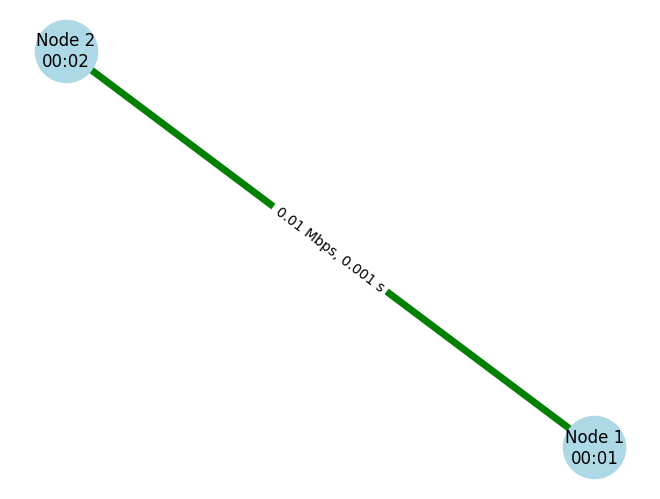

Time: 1.0 Node: 1, Event: created, Packet: 7ef9f38d-98d2-4a57-be45-28e62a3e1de8, Src: 00:01, Dst: 00:02
Time: 1.0 Node: 1, Event: sent, Packet: 7ef9f38d-98d2-4a57-be45-28e62a3e1de8, Src: 00:01, Dst: 00:02
Time: 1.001 Node: 2, Event: arrived, Packet: 7ef9f38d-98d2-4a57-be45-28e62a3e1de8, Src: 00:01, Dst: 00:02
Time: 2.0 Node: 1, Event: created, Packet: 0e570e2b-b4a0-4d52-a9cb-68f7878ad7b8, Src: 00:01, Dst: 00:02
Time: 2.0 Node: 1, Event: sent, Packet: 0e570e2b-b4a0-4d52-a9cb-68f7878ad7b8, Src: 00:01, Dst: 00:02
Time: 2.001 Node: 2, Event: arrived, Packet: 0e570e2b-b4a0-4d52-a9cb-68f7878ad7b8, Src: 00:01, Dst: 00:02
Time: 3.0 Node: 1, Event: created, Packet: 618e03df-f421-40dc-adda-3497a0b90e21, Src: 00:01, Dst: 00:02
Time: 3.0 Node: 1, Event: sent, Packet: 618e03df-f421-40dc-adda-3497a0b90e21, Src: 00:01, Dst: 00:02
Time: 3.001 Node: 2, Event: arrived, Packet: 618e03df-f421-40dc-adda-3497a0b90e21, Src: 00:01, Dst: 00:02
Time: 4.0 Node: 1, Event: created, Packet: 6b8252ad-11b4-4c7a-829d-

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec2.NetworkEventScheduler import NetworkEventScheduler
from sec2.Node import Node
from sec2.Link import Link

# グローバルネットワークイベントスケジューラのインスタンスを作成
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=True)

# ノードとリンクの設定
node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
link1 = Link(node1, node2, bandwidth=10000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
header_size = 40  # ヘッダサイズを40バイトとする
payload_size = 85  # ペイロードサイズを設定 (パケットサイズを 40 + 85 = 125バイト = 1000ビット に設定)
node1.set_traffic(destination="00:02", bitrate=1000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=header_size, payload_size=payload_size)

# イベントスケジューラを実行
network_event_scheduler.run()


### ログの確認
今回は、`verbose=True`オプションを有効化していたため、パケット生成・送信・受信に関するログが出力されました。
このログは、ネットワークシミュレーション中に発生する一連のイベントを記録したものです。
各行は、特定の時刻に特定のノードで発生したイベントと、そのイベントに関連するパケットの詳細を示しています。
以下に、ログの各部分について詳しく解説します。

#### ログの構造
各ログエントリは以下の情報を含んでいます：

- **Time:** イベントが発生した時刻。
- **Node:** イベントが発生したノードのID。
- **Event:** 発生したイベントの種類（例: `created`, `sent`, `arrived`）。
- **Packet:** イベントに関連するパケットの一意なID。
- **Src (Source):** パケットの送信元アドレス。
- **Dst (Destination):** パケットの宛先アドレス。

#### イベントの種類

- **created:** パケットが生成されたことを示します。
- **sent:** パケットが送信されたことを示します。
- **arrived:** パケットが宛先に到着したことを示します。

#### ログの例

1. `Time: 1.0 Node: 1, Event: created, Packet: c0b8f159-4788-4bec-8599-bbe399c06e7e, Src: 00:01, Dst: 00:02`
   
   時刻1.0で、ノード1がパケット`c0b8f159-4788-4bec-8599-bbe399c06e7e`を生成しました。このパケットは、送信元アドレス`00:01`から宛先アドレス`00:02`へ送られます。

2. `Time: 1.001 Node: 2, Event: arrived, Packet: c0b8f159-4788-4bec-8599-bbe399c06e7e, Src: 00:01, Dst: 00:02`
   
   時刻1.001で、ノード2がパケット`c0b8f159-4788-4bec-8599-bbe399c06e7e`を受信しました。このパケットはノード1から送られ、ノード2が宛先です。

#### ログの分析
このログを通じて、ネットワーク上でのパケットの流れ、各ノードでの処理、ネットワークの遅延（例えば、パケットが送信されてから到着するまでの時間）などを詳細に分析することができます。


### パケットログ
上記は、シミュレーション実行時のログを、基本的に時系列に沿って出力したものです。
それに対して、次に紹介するこのコードと出力は、ネットワークシミュレーション中に生成されたパケットの詳細なログを表示するものです。
以下に、コードと出力の内容について詳しく解説します。

#### コードの説明

```python
network_event_scheduler.print_packet_logs()
```

このコード行は、`network_event_scheduler`（ネットワークイベントスケジューラのインスタンス）の`print_packet_logs`メソッドを呼び出しています。このメソッドは、シミュレーション中に生成されたすべてのパケットに関するログ情報を出力します。

#### 出力の解析

出力は、各パケットに関する一連のイベントを時系列で表示しています。各セクションは以下の情報を含んでいます：

- **Packet ID:** パケットの一意な識別子。
- **Src (Source):** パケットの送信元アドレス。
- **Dst (Destination):** パケットの宛先アドレス。
- **Time:** イベントが発生した時刻。
- **Event:** 発生したイベントの種類（例: `created`, `sent`, `arrived`）。

例えば、最初のセクションは以下のように解釈できます：

- パケットID `c0b8f159-4788-4bec-8599-bbe399c06e7e` は、時刻1.0にノード1（アドレス`00:01`）によって生成され（`created`）、同じ時刻に送信され（`sent`）、時刻1.001にノード2（アドレス`00:02`）に到着しました（`arrived`）。

この出力を通じて、ネットワーク上でのパケットの流れ、各ノードでの処理、ネットワークの遅延（パケットが送信されてから到着するまでの時間）などを詳細に分析することができます。


In [ ]:
network_event_scheduler.print_packet_logs()

Packet ID: 7ef9f38d-98d2-4a57-be45-28e62a3e1de8 Src: 00:01 1.0 -> Dst: 00:02 1.001
Time: 1.0, Event: created
Time: 1.0, Event: sent
Time: 1.001, Event: arrived
Packet ID: 0e570e2b-b4a0-4d52-a9cb-68f7878ad7b8 Src: 00:01 2.0 -> Dst: 00:02 2.001
Time: 2.0, Event: created
Time: 2.0, Event: sent
Time: 2.001, Event: arrived
Packet ID: 618e03df-f421-40dc-adda-3497a0b90e21 Src: 00:01 3.0 -> Dst: 00:02 3.001
Time: 3.0, Event: created
Time: 3.0, Event: sent
Time: 3.001, Event: arrived
Packet ID: 6b8252ad-11b4-4c7a-829d-2b617804ae2c Src: 00:01 4.0 -> Dst: 00:02 4.001
Time: 4.0, Event: created
Time: 4.0, Event: sent
Time: 4.001, Event: arrived
Packet ID: 16b499a2-4118-4035-a4fc-7ec30e33c131 Src: 00:01 5.0 -> Dst: 00:02 5.001
Time: 5.0, Event: created
Time: 5.0, Event: sent
Time: 5.001, Event: arrived
Packet ID: 75f8eec7-8ab9-4d9b-8a65-e6c0bdd2d6ef Src: 00:01 6.0 -> Dst: 00:02 6.001
Time: 6.0, Event: created
Time: 6.0, Event: sent
Time: 6.001, Event: arrived
Packet ID: b040dd6a-fe9c-4204-bc8b-5631c

### トラフィックのサマリ
さらに、送信元ノードと宛先ノードのペアごとに、結果を要約する機能も紹介します。
以下に、コードと出力の内容について詳しく解説します。

#### コードの説明

```python
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
```

このコード行は、`network_event_scheduler`（ネットワークイベントスケジューラのインスタンス）の`generate_summary`メソッドを呼び出しています。このメソッドは、シミュレーション中に生成されたパケットのログデータを基に、ネットワークのパフォーマンスに関する要約情報を生成します。

#### 出力の解析

出力は、特定の送信元と宛先のペアに関するネットワークのパフォーマンス要約を示しています。各項目の意味は以下の通りです：

- **Src-Dst Pair:** パケットの送信元と宛先のペア。
- **Total Sent Packets:** 送信された総パケット数。
- **Total Sent Bytes:** 送信された総バイト数。
- **Total Received Packets:** 受信された総パケット数。
- **Total Received Bytes:** 受信された総バイト数。
- **Average Throughput (bps):** 平均スループット（ビット毎秒）。これは、ネットワークがどれだけのデータを一定時間内に処理できるかを示します。
- **Average Delay (s):** 平均遅延（秒）。これは、パケットが送信されてから受信されるまでの平均時間を示します。
- **Lost Packets:** ロストした（失われた）パケットの数。

例えば、この要約では、送信元`00:01`から宛先`00:02`への10個のパケットがすべて正常に送信され、受信されています。平均スループットは約1.344 Mbpsで、平均遅延は約1ミリ秒未満です。ロストしたパケットはありません。

#### サマリの使い方

このサマリを通じて、ネットワークの効率性、信頼性、パフォーマンスを簡潔に把握することができます。
特に、スループットと遅延はネットワークの品質を評価する上で重要な指標です。
また、パケットロスがないことは、ネットワークの信頼性が高いことを示しています。
このような指標は、ネットワークの設計や改善策を検討する際に有用な情報を提供します。


In [ ]:
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)

Src-Dst Pair: ('00:01', '00:02')
Total Sent Packets: 10
Total Sent Bytes: 1250
Total Received Packets: 10
Total Received Bytes: 1250
Average Throughput (bps): 1110.9876680368848
Average Delay (s): 0.0009999999999999343
Lost Packets: 0



### スループットの時間変化
以下のコードは、ネットワークシミュレーション中に生成されたパケットログを基に、送信元と宛先ペアごとのスループットの時間変化をグラフ化するものです。

#### コードの説明

```python
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
```

このコード行では、`network_event_scheduler`（ネットワークイベントスケジューラのインスタンス）の`generate_throughput_graph`メソッドを呼び出しています。このメソッドは、シミュレーション中に記録されたパケットログデータを使用して、スループットの時間変化をグラフとして描画します。

#### スループットの時間変化グラフ

生成されるグラフは、ネットワーク上の各送信元と宛先ペアについて、時間経過に伴うスループット（通常はビット毎秒で測定）を示します。このグラフにより、以下のような情報が得られます：

- **スループットの変動:** 特定の時間帯におけるネットワークの使用状況や負荷の変化が視覚的にわかります。
- **ピーク時の性能:** ネットワークが最も活発に使用されている時間帯や、その時のスループットの最大値が把握できます。
- **低下の原因分析:** スループットが低下する時間帯を特定し、その原因を分析するための手がかりを提供します。

#### ネットワーク分析における重要性

スループットの時間変化グラフは、ネットワークのパフォーマンス評価やトラブルシューティングにおいて重要なツールです。このグラフを通じて、ネットワークの容量計画、パフォーマンスの最適化などの手がかりを得ることができます。


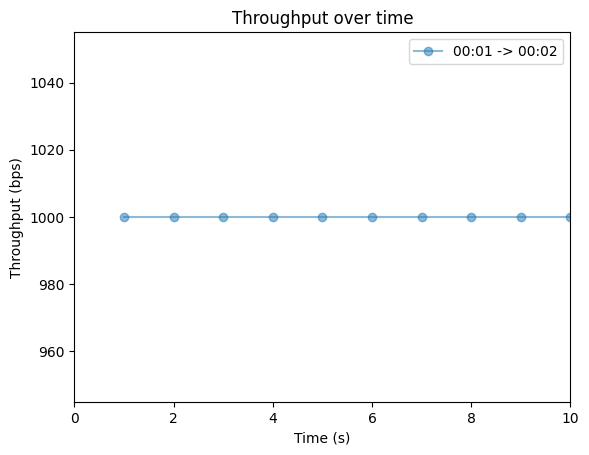

In [ ]:
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)

### 遅延ヒストグラム
以下のコードは、生成されたパケットログを基に、送信元と宛先ペアごとのパケット遅延の分布をヒストグラムとして描画するものです。

#### コードの説明

```python
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)
```

このコード行では、`network_event_scheduler`（ネットワークイベントスケジューラのインスタンス）の`generate_delay_histogram`メソッドを呼び出しています。このメソッドは、シミュレーション中に記録されたパケットログデータを使用して、パケット遅延のヒストグラムを生成します。

#### パケット遅延のヒストグラム

生成されるヒストグラムは、ネットワーク上の各送信元と宛先ペアについて、パケット遅延の分布を示します。このヒストグラムにより、以下のような情報が得られます：

- **遅延の分布:** パケットが送信されてから宛先に到着するまでの遅延時間の分布が視覚的にわかります。
- **遅延の頻度:** 特定の遅延時間がどれだけ頻繁に発生しているかが把握できます。
- **遅延の特性:** ネットワークの遅延特性を理解し、特定の遅延時間帯が支配的かどうかを分析できます。

#### ネットワーク分析における重要性

パケット遅延のヒストグラムは、ネットワークの品質とパフォーマンスを評価する上で重要なツールです。このヒストグラムを通じて、ネットワークの遅延特性を理解し、ネットワークの設計や改善策を検討する際に有用な情報を得ることができます。また、ネットワークの遅延がユーザ体験やアプリケーションのパフォーマンスに与える影響を分析するための基礎データとしても活用できます。


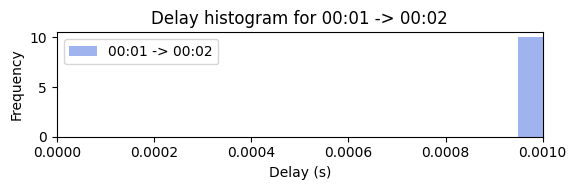

In [ ]:
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)

### 課題
1. グローバルネットワークイベントスケジューラのインスタンスを新たに作成して、2つのノードをリンクで接続し、双方向での通信を行ってみましょう。
2. トラフィックのビットレートを変えて、結果を確認してみましょう。


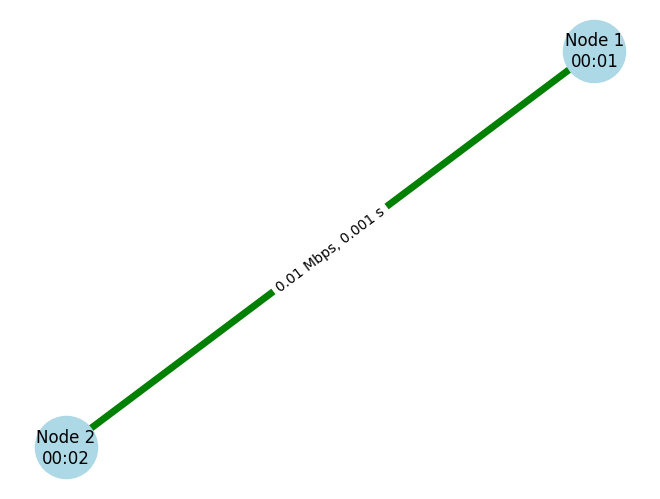

Src-Dst Pair: ('00:01', '00:02')
Total Sent Packets: 10
Total Sent Bytes: 1250
Total Received Packets: 10
Total Received Bytes: 1250
Average Throughput (bps): 1110.9876680368848
Average Delay (s): 0.0009999999999999343
Lost Packets: 0

Src-Dst Pair: ('00:02', '00:01')
Total Sent Packets: 30
Total Sent Bytes: 3750
Total Received Packets: 30
Total Received Bytes: 3750
Average Throughput (bps): 5171.52215135321
Average Delay (s): 0.0010000000000001859
Lost Packets: 0



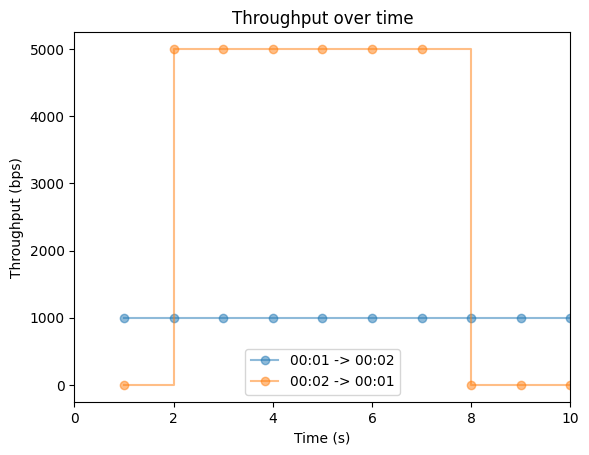

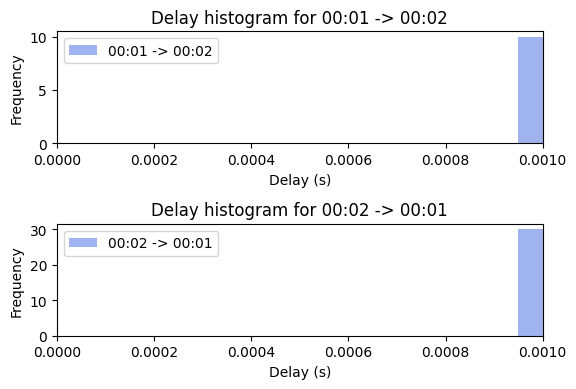

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec2.NetworkEventScheduler import NetworkEventScheduler
from sec2.Node import Node
from sec2.Link import Link
from sec2.Packet import Packet

# グローバルネットワークイベントスケジューラのインスタンスを新たに作成
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)

# ノードとリンクの設定
node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
link1 = Link(node1, node2, bandwidth=10000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination="00:02", bitrate=1000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)
# ノード2 → ノード1 のビットレートを5000bpsに設定
node2.set_traffic(destination="00:01", bitrate=5000, start_time=2.0, duration=6.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)

3. もう少し現実的な条件に近づけて、リンクの帯域を100kbpsに設定してみましょう。
4. トラフィックのビットレートを大きくしてみましょう。特に、リンク帯域を超える速度になると混雑が発生（いわゆる「パケ詰まり」の状況）して、遅延が大きくなることを確認しましょう。
5. パケットロス率を0.2などに設定して、パケットロスが発生することを確認してみましょう。これは、「電波が弱い」ような状況を模擬しており、ロス率が高くなるとパケットがなかなか届かなくなることを確認しましょう。


Src-Dst Pair: ('00:01', '00:02')
Total Sent Packets: 501
Total Sent Bytes: 62625
Total Received Packets: 409
Total Received Bytes: 51125
Average Throughput (bps): 40895.9104089597
Average Delay (s): 0.0009999999999999387
Lost Packets: 92

Src-Dst Pair: ('00:02', '00:01')
Total Sent Packets: 1201
Total Sent Bytes: 150125
Total Received Packets: 961
Total Received Bytes: 120125
Average Throughput (bps): 79678.30196501261
Average Delay (s): 3.0488251821019494
Lost Packets: 240



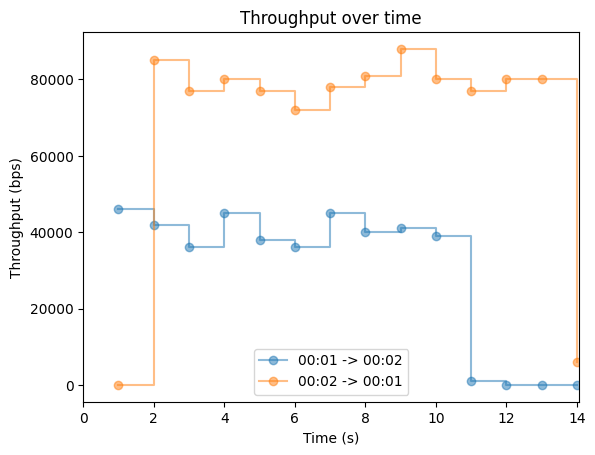

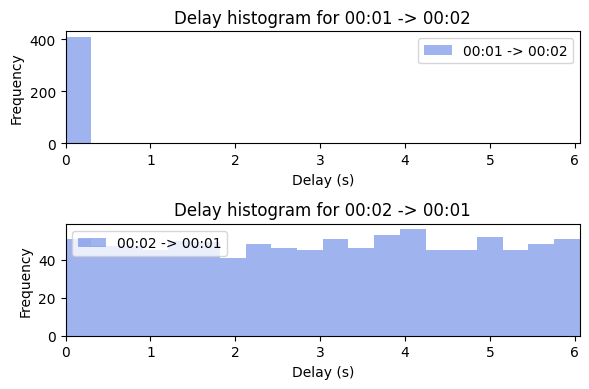

In [ ]:
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)

node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
# リンクの帯域を100kbpsに設定
link1 = Link(node1, node2, bandwidth=100000, delay=0.001, loss_rate=0.2, network_event_scheduler=network_event_scheduler)

node1.set_traffic(destination="00:02", bitrate=50000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)
node2.set_traffic(destination="00:01", bitrate=200000, start_time=2.0, duration=6.0, burstiness=1.0, header_size=40, payload_size=85)

network_event_scheduler.run()

network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)

## 演習課題

本章で作成したクラスをインポートして利用する場合には、以下のように記述・実行してください。
```
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')
```
```
from sec2.NetworkEventScheduler import NetworkEventScheduler
from sec2.Node import Node
from sec2.Link import Link
```

### 演習課題1: パケット転送時間の測定
**目的**: ネットワーク上でのパケット転送時間を測定する。

**手順**:
1. 特定のサイズのパケットを作成する。
2. リンクの帯域幅を指定し、パケット転送時間を測定する。
3. 異なる帯域幅で転送時間がどのように変化するか観察する。

### 演習課題2: ネットワークの遅延とスループットの測定
**目的**: 異なるネットワーク条件下での遅延とスループットを測定する。

**手順**:
1. 2つのノードとリンクを使ってネットワークを構築する。
2. パケットを送信し、遅延とスループットを測定する。
3. 異なるリンク条件（帯域幅、遅延）でこれらの指標がどのように変化するか分析する。

### 演習課題3: パケットロス率とネットワークパフォーマンスの関係

#### 目的
ネットワークの異なるパケットロス率におけるパフォーマンス（特に遅延とスループット）を測定し、結果をグラフ化する。

#### 手順
1. **ネットワークの構築**: ノードとリンクを使って基本的なネットワークを構築する。
2. **パケットロス率の設定**: リンクに対して異なるパケットロス率（例: 0%, 5%, 10%, 15%）を設定する。
3. **パケットの送信**: 指定されたパケットロス率でノード間にパケットを送信する。
4. **パフォーマンス指標の測定**: それぞれのロス率での遅延とスループットを測定する。
5. **データの収集とグラフ化**: 測定したデータを収集し、ロス率に対する遅延とスループットの関係をグラフ化する。


## 本章のまとめ
本章では、コンピュータネットワークにおいて重要な要素となる時間の概念を導入しました。
これでパケットが時間的にどういった順序で処理され、目的地まで到達するのか、をコンピュータ上でトレースすることができます。
またスループットや遅延、ロス率などの指標を導入し、ネットワークサービスの品質を評価できるようにしました。
「大きなファイルを送信するためには、それなりに時間がかかる」「ネットワークが混雑するとパケ詰まりが発生する」など、日常で体感しているような事象をシミュレーションで確認できます。

通信の仕組みやプロトコルなどを学ぶような類書ではあまり見かけないアプローチですが、「作りながら学ぶ」ためには必要なステップでした。
今後様々な機能を「作って」いくための準備として、シミュレータの拡張性を高めておく必要があったため、少々コードが長くなり、煩雑な部分も出てきてしまいました。
本章の内容がよく分からなかったとしても、次章以降の学習には直接的には影響しないはずです。
ですので、コードの長さに挫けず、安心して進めていただけたらと思います。



